# Coursework 1 Group 26

Group number: 26

Student names and k-numbers:
1. Amir Mostafa Ramezannezhad K2416621
2. Darren Mounganga K1714588
3. Sasindu Mihiran Piyarathna K2453742
4. Srilasan Manijam K2111062






# Load modules

In [ ]:
# Loading dataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize


# Loading Classification models
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Loading Metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, balanced_accuracy_score


# Loading plots and graph modules
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from prettytable import PrettyTable


In [ ]:
# Creating a function code for a table metrics
def table_metrics(table_name, model_acc, model_roc_auc, best_model_acc, best_model_roc_auc):

    # creating tables
    table_name = PrettyTable()
    table_name.field_names = ["Metric", "Initial Model", "Final Model"]
    table_name.add_row(["Balanced Accuracy", model_acc, best_model_acc])
    table_name.add_row(["ROC AUC (macro averaged)", model_roc_auc, best_model_roc_auc])

    #return table_name
    print(table_name)

# Load Data

In [ ]:
### Loading the data
digits = load_digits()

### train will have 80% of the data
### test will have the remaining 20% of the data

X = digits.data
y = digits.target


# Splitting the datas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 26, stratify=y)

# Binarize the labels for ROC AUC calculation
y_test_binarized = label_binarize(y_test, classes=range(10))

<Figure size 640x480 with 0 Axes>

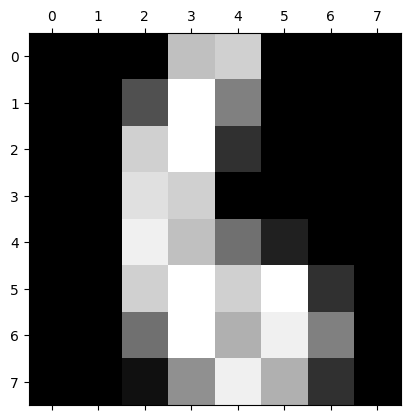

In [ ]:
plt.gray()
plt.matshow(digits.images[6])
plt.show()

In [ ]:
# Checking the data size

print(f'Training data shape (X): {X_train.shape}')
print(f'Test data shape (X): {X_test.shape}')
print(f'Training data shape (y): {y_train.shape}')
print(f'Test data shape(y): {y_test.shape}')

Training data shape (X): (1437, 64)
Test data shape (X): (360, 64)
Training data shape (y): (1437,)
Test data shape(y): (360,)


In [ ]:
digits.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

[178 182 177 183 181 182 181 179 174 180]
Class 0: 178 samples (9.91%)
Class 1: 182 samples (10.13%)
Class 2: 177 samples (9.85%)
Class 3: 183 samples (10.18%)
Class 4: 181 samples (10.07%)
Class 5: 182 samples (10.13%)
Class 6: 181 samples (10.07%)
Class 7: 179 samples (9.96%)
Class 8: 174 samples (9.68%)
Class 9: 180 samples (10.02%)


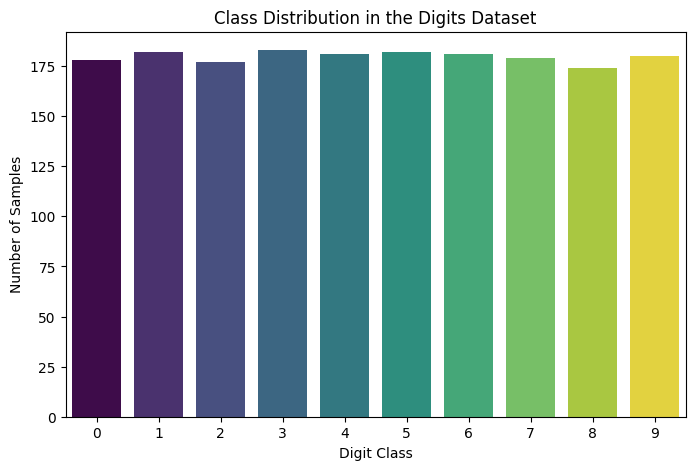

In [ ]:
# Count occurrences of each class
class_counts = np.bincount(y)
print(class_counts)
class_percentages = class_counts / len(y) * 100  # Convert to percentage

# Print class distribution
for i, count in enumerate(class_counts):
    print(f"Class {i}: {count} samples ({class_percentages[i]:.2f}%)")

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=np.arange(10), y=class_counts, hue = np.arange(10), palette="viridis", legend=False)
plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in the Digits Dataset")
plt.show()

It shows that the Digits dataset is balanced.

# Classification

## Classification methods used

1.   Logistic Regression
2.   Decision Trees
3.   Random Forest
4.   Support Vector Machine (SVM)
5.   Linear Discriminant Analysis (LDA)
6.   k-Nearest Neighbours (k-NN)
7.   Naïve Bayes
8.   XGBoost (Chen & Contributors, n.d.)



## Classification 1 - Logistic Regression

In [ ]:
# Initialise and Train Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=26)
lr_clf.fit(X_train, y_train)

# Make Predictions
lr_pred = lr_clf.predict(X_test)

### Evaluate the L.Regression model

In [ ]:
# Evaluate the Model
lr_acc = accuracy_score(y_test, lr_pred)
lr_cm = confusion_matrix(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test_binarized, lr_clf.predict_proba(X_test), multi_class='ovr')

# Print Evaluation Metrics
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Logistic Regression ROC AUC: {lr_roc_auc:.4f}")
print("Logistic Regression Confusion Matrix:\n", lr_cm)

Logistic Regression Accuracy: 0.9750
Logistic Regression ROC AUC: 0.9994
Logistic Regression Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  1  0  0  1  1]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  1 34  0  0  0  1]
 [ 0  0  0  0  0  1 35  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 1  1  0  0  0  0  0  0 32  1]
 [ 0  0  0  0  0  0  0  0  0 36]]


### Hyper Parameter Tuning

In [ ]:
# Define the hyperparameter grid
lr_params = {
    'C': [0.01, 0.1, 1, 10],        # Regularisation strength
    'penalty': ['l1', 'l2'],        # Norm used in penalisation
    'solver': ['liblinear']         # Solver that supports L1 and L2
}

# Setup GridSearchCV
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=26), lr_params, cv=5)
lr_grid.fit(X_train, y_train)

# Best model after hyperparameter tuning
lr_best = lr_grid.best_estimator_

# Evaluate the optimised model
lr_best_pred = lr_best.predict(X_test)
lr_best_acc = accuracy_score(y_test, lr_best_pred)
lr_best_roc_auc = roc_auc_score(y_test_binarized, lr_best.predict_proba(X_test), multi_class='ovr')

# Print the best parameters and evaluation metrics
print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print(f"Optimised Logistic Regression Accuracy: {lr_best_acc:.4f}")
print(f"Optimised Logistic Regression ROC AUC: {lr_best_roc_auc:.4f}")

Best Logistic Regression Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Optimised Logistic Regression Accuracy: 0.9667
Optimised Logistic Regression ROC AUC: 0.9980


In [ ]:
# Creating a Logistic Regression table
lr_table = PrettyTable()
table_metrics(lr_table, lr_acc, lr_roc_auc, lr_best_acc, lr_best_roc_auc)

+--------------------------+--------------------+--------------------+
|          Metric          |   Initial Model    |    Final Model     |
+--------------------------+--------------------+--------------------+
|    Balanced Accuracy     |       0.975        | 0.9666666666666667 |
| ROC AUC (macro averaged) | 0.9994237449615906 | 0.9979869017797869 |
+--------------------------+--------------------+--------------------+


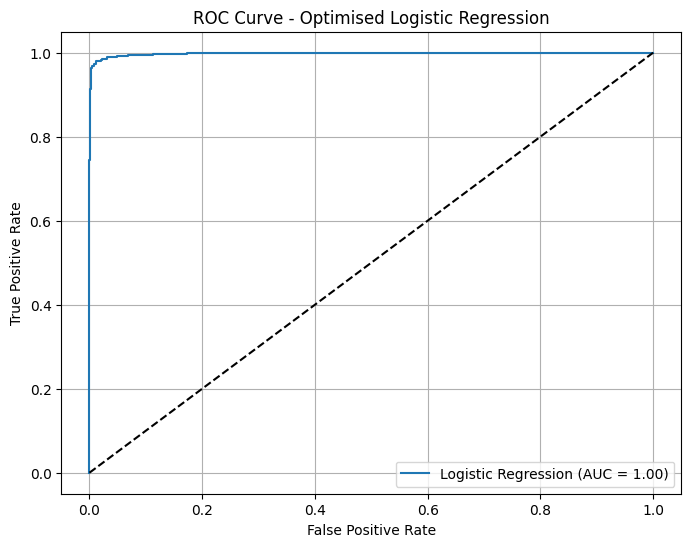

In [ ]:
# ROC Curve for Logistic Regression
# ROC Curve for the optimised Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test_binarized.ravel(), lr_best.predict_proba(X_test).ravel())

# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_best_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimised Logistic Regression')
plt.legend()
plt.grid()
plt.show()

## Classification 2 - Decision Trees

In [ ]:
# Initialise and Train Decision Tree
dt_clf = DecisionTreeClassifier(random_state=26)
dt_clf.fit(X_train, y_train)

# Make Predictions
dt_pred = dt_clf.predict(X_test)

### Evaluate the Decision Tree model

In [ ]:
# Evaluate the Model
dt_acc = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test_binarized, dt_clf.predict_proba(X_test), multi_class='ovr')

# Print Evaluation Metrics
print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Decision Tree ROC AUC: {dt_roc_auc:.4f}")
print("Decision Tree Confusion Matrix:\n", dt_cm)

Decision Tree Accuracy: 0.8611
Decision Tree ROC AUC: 0.9228
Decision Tree Confusion Matrix:
 [[34  0  1  0  0  0  0  0  1  0]
 [ 0 34  1  0  0  0  0  0  1  1]
 [ 1  3 27  0  0  0  0  1  3  0]
 [ 0  1  1 28  1  0  0  2  2  2]
 [ 0  0  0  0 32  2  1  1  0  0]
 [ 0  0  0  2  2 31  0  0  0  1]
 [ 0  1  0  0  0  1 34  0  0  0]
 [ 2  0  0  0  0  0  0 31  2  1]
 [ 0  0  1  0  1  0  0  1 31  1]
 [ 1  1  2  2  0  0  0  1  1 28]]


### Hyper Parameter Tuning

In [ ]:
# Define hyperparameters grid
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Grid Search with 5-fold Cross-Validation
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=26), dt_params, cv=5)
dt_grid.fit(X_train, y_train)

# Tuning
dt_best = dt_grid.best_estimator_
print("Best Decision Tree Parameters:", dt_grid.best_params_)


Best Decision Tree Parameters: {'max_depth': 20, 'min_samples_split': 2}


In [ ]:
dt_best_pred = dt_best.predict(X_test)
dt_best_acc = accuracy_score(y_test, dt_best_pred)
dt_best_roc_auc = roc_auc_score(y_test_binarized, dt_best.predict_proba(X_test), multi_class='ovr')


print(f"Optimised Decision Tree Accuracy: {dt_best_acc:.4f}")
print(f"Optimised Decision Tree ROC AUC: {dt_best_roc_auc:.4f}")

Optimised Decision Tree Accuracy: 0.8611
Optimised Decision Tree ROC AUC: 0.9228


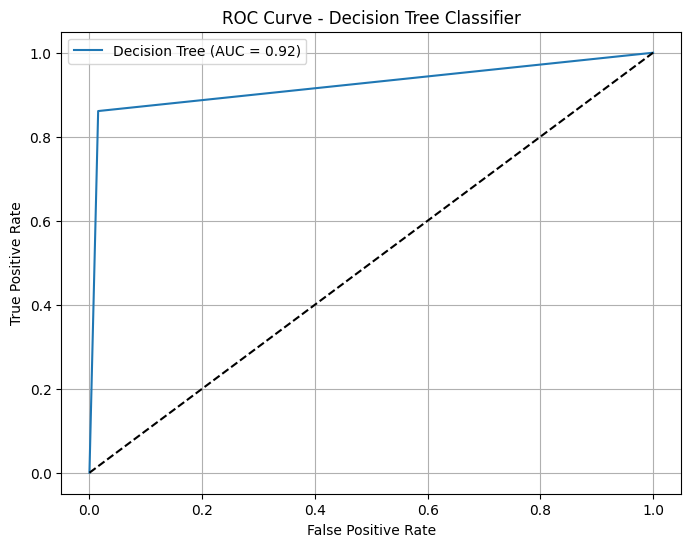

In [ ]:
# ROC Curve for Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test_binarized.ravel(), dt_clf.predict_proba(X_test).ravel())

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree Classifier')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Creating a Decision Tree table
dt_table = PrettyTable()
table_metrics(dt_table, dt_acc, dt_roc_auc, dt_best_acc, dt_best_roc_auc)

+--------------------------+--------------------+--------------------+
|          Metric          |   Initial Model    |    Final Model     |
+--------------------------+--------------------+--------------------+
|    Balanced Accuracy     | 0.8611111111111112 | 0.8611111111111112 |
| ROC AUC (macro averaged) | 0.9228165857484744 | 0.9228165857484744 |
+--------------------------+--------------------+--------------------+


## Classification 3 - Random Forest

In [ ]:
### Loading the Random Forest Classifier

rfc = RandomForestClassifier(random_state=26, max_depth = 20)

### Fitting the data into the model and train

rfc.fit(X_train, y_train)

### Predictions

rfc_y_pred = rfc.predict(X_test)

### Evaluating the model

In [ ]:
### Classification Report
print('Below displays the Classification Report on the Model: \n\n',classification_report(y_test, rfc_y_pred))

Below displays the Classification Report on the Model: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        37
           2       0.97      1.00      0.99        35
           3       1.00      0.95      0.97        37
           4       1.00      0.97      0.99        36
           5       0.97      0.97      0.97        36
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.97      0.99        35
           9       0.95      1.00      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [ ]:
### Accuracy Score and ROC AUC Score

rfc_accuracy = accuracy_score(y_test,rfc_y_pred)
rfc_roc_auc = roc_auc_score(y_test, rfc.predict_proba(X_test), multi_class='ovr')
print(f'RFC Accuracy Score: {rfc_accuracy:.4f}')
print(f'RFC ROC AUC Score: {rfc_roc_auc:.4f}')

RFC Accuracy Score: 0.9833
RFC ROC AUC Score: 0.9995


<Figure size 1600x1200 with 0 Axes>

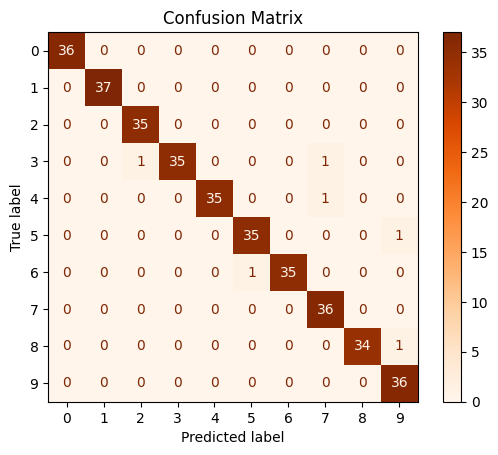

In [ ]:
### Confusion Matrix
plt.figure(figsize = (8,6), dpi = 200);

rfc_cm = confusion_matrix(y_test, rfc_y_pred);

disp = ConfusionMatrixDisplay(confusion_matrix=rfc_cm);


disp.plot(cmap='Oranges');
plt.title('Confusion Matrix');

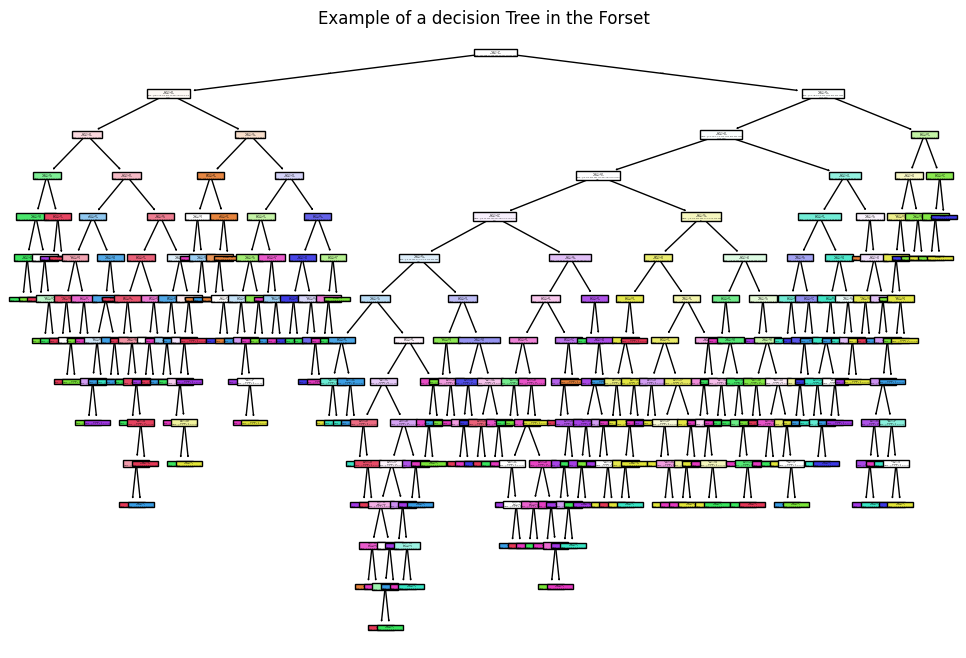

In [ ]:
individual_tree = rfc.estimators_[0]
plt.figure(figsize=(12,8))
plot_tree(individual_tree, filled=True)
plt.title('Example of a decision Tree in the Forset')
plt.show()

### Hypertuning

In [ ]:
### Checking the Model Parameters
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 26,
 'verbose': 0,
 'warm_start': False}

In [ ]:
### Tuning different parameters

#parameters = {'n_estimators' : [40],
#              'criterion' : ['entropy'],
#              'random_state' : [26],
#              'max_depth' : [7],
#              'bootstrap' : [True]}

parameters = {'n_estimators' : [20, 40, 60],
              'criterion' : ['gini','entropy'],
              'max_depth' : [None, 5, 10],
              'max_samples': [None, 0.5, 0.75],
              'bootstrap' : [True]}

#### Selecting a second Random Forest Classifier model and grid search
rfc2 = RandomForestClassifier()
grfc = GridSearchCV(rfc2, parameters)

### Train the data
grfc.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True], 'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10],
                         'max_samples': [None, 0.5, 0.75],
                         'n_estimators': [20, 40, 60]})

In [ ]:
### Retrieving the best estimators
best_rfc = grfc.best_estimator_
print(f'Best Estimators: \n {best_rfc}')
### Retrieving the best Parameters
best_rfc_params = grfc.best_params_
print(f'Best Parameters: \n {best_rfc_params}')

Best Estimators: 
 RandomForestClassifier(criterion='entropy', n_estimators=60)
Best Parameters: 
 {'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_samples': None, 'n_estimators': 60}


In [ ]:
### Second Model Prediciton
rfc_best_pred = best_rfc.predict(X_test)

### Classification Report of the best Model

print('Below displays the Classification Report on the Model: \n\n',classification_report(y_test, rfc_best_pred))

Below displays the Classification Report on the Model: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        37
           2       1.00      0.97      0.99        35
           3       0.97      0.92      0.94        37
           4       1.00      0.97      0.99        36
           5       0.94      0.94      0.94        36
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.97      1.00      0.99        35
           9       0.95      0.97      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



In [ ]:
# Evaluating the optimised model
best_rfc_accuracy = accuracy_score(y_test, rfc_best_pred)
best_rfc_roc_auc = roc_auc_score(y_test, best_rfc.predict_proba(X_test), multi_class='ovr')
print(f'RFC Accuracy Score: {best_rfc_accuracy:.4f}')
print(f'RFC ROC AUC Score: {rfc_roc_auc:.4f}')

RFC Accuracy Score: 0.9750
RFC ROC AUC Score: 0.9995


In [ ]:
# Creating a Random Forest metric table
print("\nImprovement:", f"{(best_rfc_accuracy - rfc_accuracy) * 100:.2f}%" if best_rfc_accuracy > rfc_accuracy else "No improvement")
rfc_table = PrettyTable()
table_metrics(rfc_table, rfc_accuracy, rfc_roc_auc, best_rfc_accuracy, best_rfc_roc_auc)


Improvement: No improvement
+--------------------------+--------------------+--------------------+
|          Metric          |   Initial Model    |    Final Model     |
+--------------------------+--------------------+--------------------+
|    Balanced Accuracy     | 0.9833333333333333 |       0.975        |
| ROC AUC (macro averaged) | 0.9995313658548236 | 0.9995593731356086 |
+--------------------------+--------------------+--------------------+


<Figure size 1600x1200 with 0 Axes>

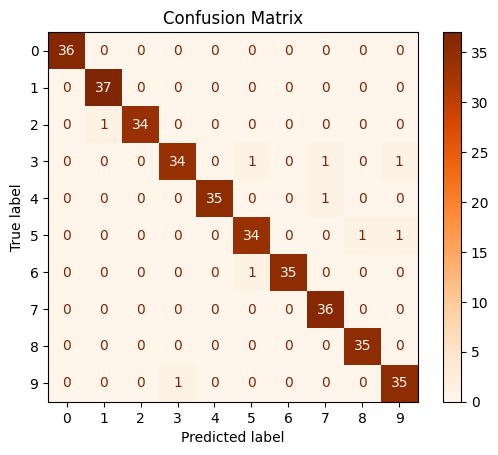

In [ ]:
### Confusion Matrix
plt.figure(figsize = (8,6), dpi = 200);

rfc_cm = confusion_matrix(y_test, rfc_best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=rfc_cm);


disp.plot(cmap='Oranges');
plt.title('Confusion Matrix');

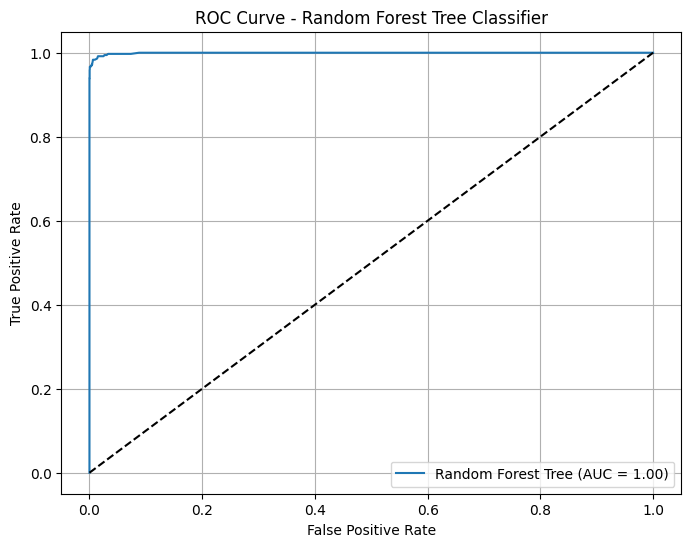

In [ ]:
# ROC Curve for Random Forest Tree
rfc_fpr, rfc_tpr, _ = roc_curve(y_test_binarized.ravel(), rfc.predict_proba(X_test).ravel())

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(rfc_fpr, rfc_tpr, label=f'Random Forest Tree (AUC = {rfc_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Tree Classifier')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ROC Curve and AUC Score Calculation
rf_y_score = rfc.predict_proba(X_test)
rf_n_classes = 10

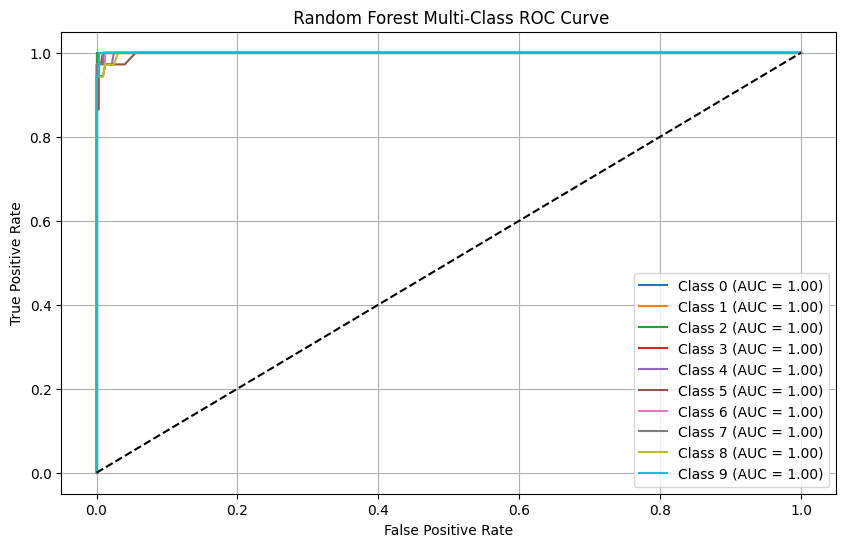

In [ ]:
# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 6))
for i in range(rf_n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], rf_y_score[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], rf_y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" Random Forest Multi-Class ROC Curve")
plt.legend()
plt.grid()
plt.show()

## Classification 4 - Support Vector Machine (Non-linear Kernals)

### RBF SVM - Preprocessing and Training the initial model

Radial Basis Function was selected as the Kernal for explaining SVM clasification due to,
1. Handle complex data structure in 'digits' dataset. ie. image recognition by mapping vectors into high dimensions
2. dataset is not linearly seperable
3. rbf maintain good balance between bias and variance (good generalization)

In [ ]:
# let's train the model with a default parameter values for gamma and 'C'
model = SVC(kernel='rbf', C=10, gamma = 0.01, probability=True)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

#### Evaluating the Initial Model

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred)
svm_balanced_acc = balanced_accuracy_score(y_test, y_pred)
conf_matrix_initial = confusion_matrix(y_test, y_pred)
svm_roc_auc = roc_auc_score(y_test_binarized, y_prob, average='macro', multi_class='ovr')

print("Accuracy:", svm_accuracy)
print("Balanced Accuracy:", svm_balanced_acc)
print("Confusion Matrix_initial:\n", conf_matrix_initial)
print("ROC AUC (macro averaged):", svm_roc_auc)
# print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8472222222222222
Balanced Accuracy: 0.8478635778635779
Confusion Matrix_initial:
 [[28  0  0  0  0  0  0  0  8  0]
 [ 0 30  0  0  0  0  0  0  7  0]
 [ 0  0 27  0  0  0  0  0  8  0]
 [ 0  0  0 27  0  0  0  0 10  0]
 [ 0  0  0  0 33  0  0  0  3  0]
 [ 0  0  0  0  0 33  0  0  3  0]
 [ 0  0  0  0  0  0 28  0  8  0]
 [ 0  0  0  0  0  0  0 31  5  0]
 [ 0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0  0  3 33]]
ROC AUC (macro averaged): 0.9995535303516785


#### Hyper-tuning of the parameters

Grid Search CV can be used to efectively run the model iteratively and find the best parameters

In [ ]:
# Define the parameter grid for gamma and C
param_grid = {
    'gamma': [1e-2, 1e-3, 1e-4, 1e-5],
    'C': [1, 10, 100]
}

# Create a GridSearchCV object with SVC and the parameter grid
grid_search = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)


Best Parameters: {'C': 10, 'gamma': 0.001}
Best Cross-Validation Score: 0.9909601238869532


let's try to drill down grid search range to see if the best parameters change


In [ ]:
# Define the parameter grid for gamma and C
C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
param_grid_expand = dict(gamma=gamma_range, C=C_range)

# Create a GridSearchCV object with SVC and the parameter grid
from sklearn.model_selection import StratifiedShuffleSplit
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid_search_expand = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring='accuracy')

# Fit the grid search to the data
grid_search_expand.fit(X_train, y_train)

# Get the best parameters and best score
best_params_expand = grid_search_expand.best_params_
best_score_expand = grid_search_expand.best_score_

print("Best Parameters from expanded grid search:", best_params_expand)
print("Best Cross-Validation Score from expanded grid search:", best_score_expand)

Best Parameters from expanded grid search: {'C': 10, 'gamma': 0.001}
Best Cross-Validation Score from expanded grid search: 0.9902777777777778


let's chose the parameters given by the second grid search and proceed

#### Train the final RBF model with hyper-tuned parameters

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)

#### Evaluating the final model against the initial model




In [ ]:
accuracy_best = accuracy_score(y_test, y_pred_best)
balanced_acc_best = balanced_accuracy_score(y_test, y_pred_best)
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test_binarized, y_prob_best, average='macro', multi_class='ovr')

print("Best Model Accuracy:", accuracy_best)
print("Best Model Balanced Accuracy:", balanced_acc_best)
print("Best Model Confusion Matrix:\n", conf_matrix_best)
print("Best Model ROC AUC (macro averaged):", roc_auc_best)
# print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

Best Model Accuracy: 0.9944444444444445
Best Model Balanced Accuracy: 0.9945195195195196
Best Model Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  0  0  1  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 35  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0  0  0 36]]
Best Model ROC AUC (macro averaged): 0.9995541838134431


In [ ]:
# Creating a Support Vector Machine metric table

svm_table = PrettyTable()
table_metrics(svm_table, svm_balanced_acc, svm_roc_auc, balanced_acc_best, roc_auc_best)

+--------------------------+--------------------+--------------------+
|          Metric          |   Initial Model    |    Final Model     |
+--------------------------+--------------------+--------------------+
|    Balanced Accuracy     | 0.8478635778635779 | 0.9945195195195196 |
| ROC AUC (macro averaged) | 0.9995535303516785 | 0.9995541838134431 |
+--------------------------+--------------------+--------------------+


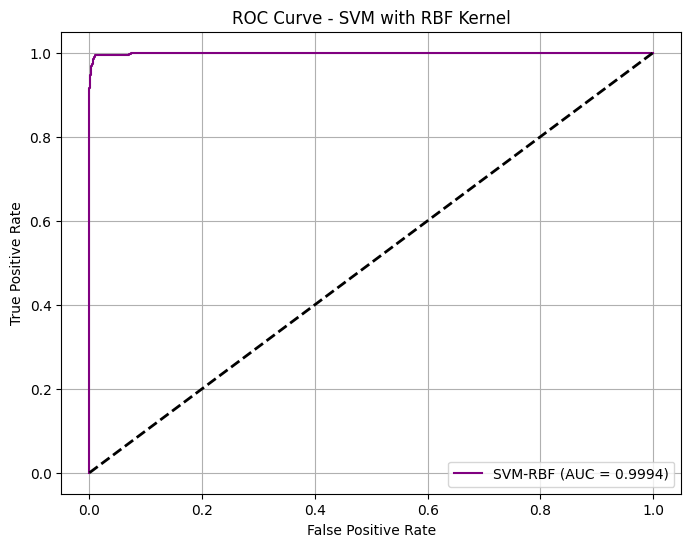

In [ ]:
# 4. Compute ROC curve and AUC score
y_score_svm = best_model.predict_proba(X_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test_binarized.ravel(), y_score_svm.ravel())
auc_svm = roc_auc_score(y_test_binarized, y_score_svm, average="macro")

# 5. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM-RBF (AUC = {auc_svm:.4f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Reference line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM with RBF Kernel')
plt.legend()
plt.grid()
plt.show()

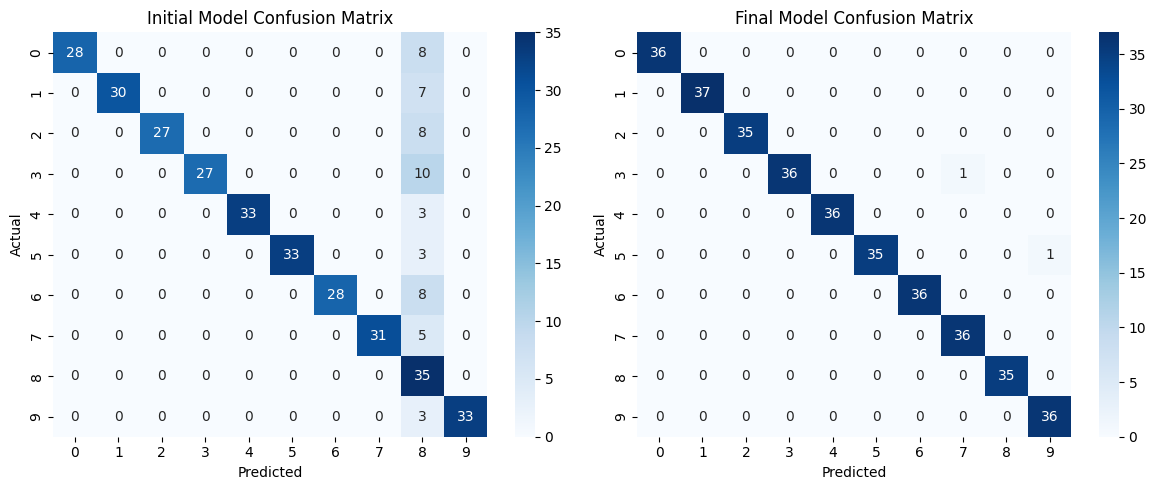

In [ ]:
# Plot the confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_initial, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Initial Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Final Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Polynomial SVM - Preprocessing and Training the default model

In [ ]:
# since all the preprocessing except standard scaler has already been done,

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Create a polynomial SVM classifier
from sklearn.svm import SVC
svm_poly = SVC(kernel='poly', degree=5, C=1.0)

# Train the classifier
svm_poly.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_poly.predict(X_test)

#### Evaluating the default Model

In [ ]:
# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 0.6916666666666667
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.72      0.84        36
           1       1.00      0.70      0.83        37
           2       1.00      0.63      0.77        35
           3       1.00      0.49      0.65        37
           4       1.00      0.89      0.94        36
           5       1.00      0.44      0.62        36
           6       1.00      0.83      0.91        36
           7       0.93      0.69      0.79        36
           8       0.24      1.00      0.39        35
           9       1.00      0.53      0.69        36

    accuracy                           0.69       360
   macro avg       0.92      0.69      0.74       360
weighted avg       0.92      0.69      0.74       360



In [ ]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Calculate the ROC AUC score (macro averaged)
# For ROC AUC, we need to binarize the output
y_test_binarized = label_binarize(y_test, classes=np.arange(10))
y_pred_binarized = label_binarize(y_pred, classes=np.arange(10))

print("Confusion Matrix:")
print(conf_matrix)
print(f"Balanced Accuracy: {balanced_acc}")

Confusion Matrix:
[[26  0  0  0  0  0  0  0 10  0]
 [ 0 26  0  0  0  0  0  0 11  0]
 [ 0  0 22  0  0  0  0  0 13  0]
 [ 0  0  0 18  0  0  0  0 19  0]
 [ 0  0  0  0 32  0  0  1  3  0]
 [ 0  0  0  0  0 16  0  0 20  0]
 [ 0  0  0  0  0  0 30  0  6  0]
 [ 0  0  0  0  0  0  0 25 11  0]
 [ 0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0  1 16 19]]
Balanced Accuracy: 0.6928871728871728


ROC AUC (Macro Averaged): 0.829365713699047


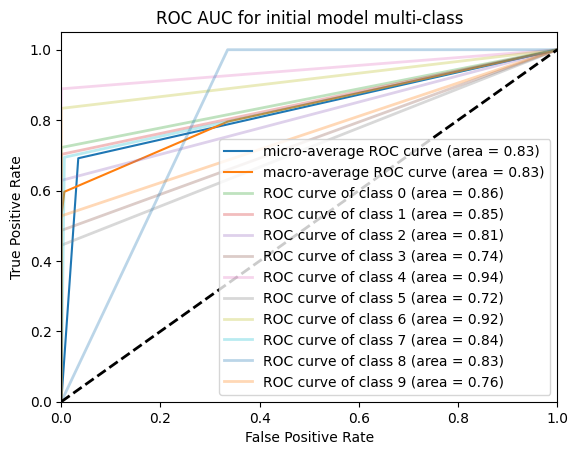

In [ ]:
from sklearn.metrics import auc

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_binarized.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 10

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"ROC AUC (Macro Averaged): {roc_auc['macro']}")
# Plot ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]))
for i in range(10):
    plt.plot(fpr[i], tpr[i], lw=2, alpha=0.3,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC for initial model multi-class')
plt.legend(loc="lower right")
plt.show()

#### Hyper-tuning the poly model

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'degree': [1, 2, 3, 4, 5, 6, 7, 8],
    'kernel': ['poly']
}
# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=svm_poly, param_grid=param_grid, cv=5, scoring='accuracy')

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score}")

Best Parameters: {'C': 10, 'degree': 3, 'kernel': 'poly'}
Best Cross-Validation Score: 0.9839987417731321


let's drill down on the suggested parameters to find a more suitable set

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [7,8,9,10,11,12,13],
    'degree': [1, 2, 3, 4, 5],
    'kernel': ['poly']
}
# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=svm_poly, param_grid=param_grid, cv=5, scoring='accuracy')

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params_zoomed = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters_zoomed: {best_params_zoomed}")
print(f"Best Cross-Validation Score: {best_score}")

Best Parameters_zoomed: {'C': 7, 'degree': 3, 'kernel': 'poly'}
Best Cross-Validation Score: 0.9853900503290747


Train the parameter tuned model

In [ ]:
# Train the classifier with the best parameters (zoomed in)
svm_poly_best_zoomed = SVC(**best_params_zoomed)
svm_poly_best_zoomed.fit(X_train, y_train)

# Make predictions on the test set
y_pred_best = svm_poly_best_zoomed.predict(X_test)

#### Evaluating the final model against the initial model

In [ ]:
# Evaluate the classifier with the best parameters (zoomed in)
accuracy_best_zoomed = accuracy_score(y_test, y_pred_best)
report_best_zoomed = classification_report(y_test, y_pred_best)

# Calculate the balanced accuracy
balanced_acc_best = balanced_accuracy_score(y_test, y_pred_best)

# Calculate the confusion matrix
conf_matrix_best = confusion_matrix(y_test, y_pred_best)

print(f"Accuracy with Best Parameters (Zoomed In): {accuracy_best_zoomed}")
print(f"Balanced Accuracy_best: {balanced_acc_best}")
print("Classification Report:")
print(report_best_zoomed)
print("Confusion Matrix_best:")
print(conf_matrix_best)



Accuracy with Best Parameters (Zoomed In): 0.9861111111111112
Balanced Accuracy_best: 0.9863363363363362
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        35
           3       1.00      0.92      0.96        37
           4       1.00      1.00      1.00        36
           5       1.00      0.97      0.99        36
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       0.95      1.00      0.97        35
           9       0.95      0.97      0.96        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

Confusion Matrix_best:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  

ROC AUC (Macro Averaged): 0.9923975128975129


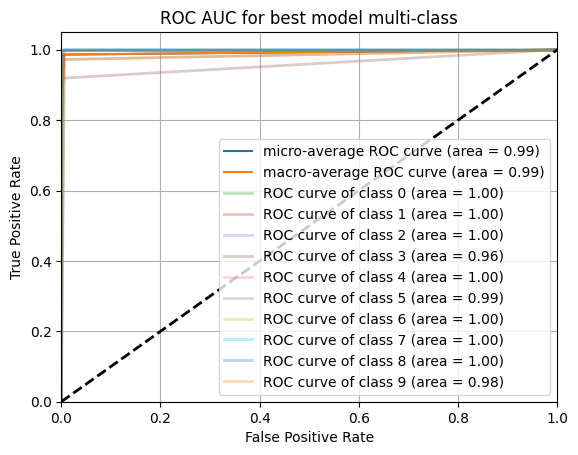

In [ ]:
# Compute ROC curve and ROC area for each class

# Calculate the ROC AUC score (macro averaged)
# For ROC AUC, we need to binarize the output
y_test_binarized = label_binarize(y_test, classes=np.arange(10))
y_pred_binarized = label_binarize(y_pred_best, classes=np.arange(10))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_binarized.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 10

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"ROC AUC (Macro Averaged): {roc_auc['macro']}")
# Plot ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]))
for i in range(10):
    plt.plot(fpr[i], tpr[i], lw=2, alpha=0.3,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC for best model multi-class')
plt.legend(loc="lower right")
plt.grid()
plt.show()

ROC AUC curve when compared with initial model, show a significant improvement on all metrics

In [ ]:
# Creating a Support Vector Machine metric table
table = PrettyTable()

# Add columns
table.field_names = ["poly Models", "Accuracy"]
table.add_row(["Initial poly Model", f"{balanced_acc * 100:.2f}%"])
table.add_row(["Final poly Model (Hyperparameter Tuned)", f"{balanced_acc_best * 100:.2f}%"])

# Print the table
print(table)

+-----------------------------------------+----------+
|               poly Models               | Accuracy |
+-----------------------------------------+----------+
|            Initial poly Model           |  69.29%  |
| Final poly Model (Hyperparameter Tuned) |  98.63%  |
+-----------------------------------------+----------+


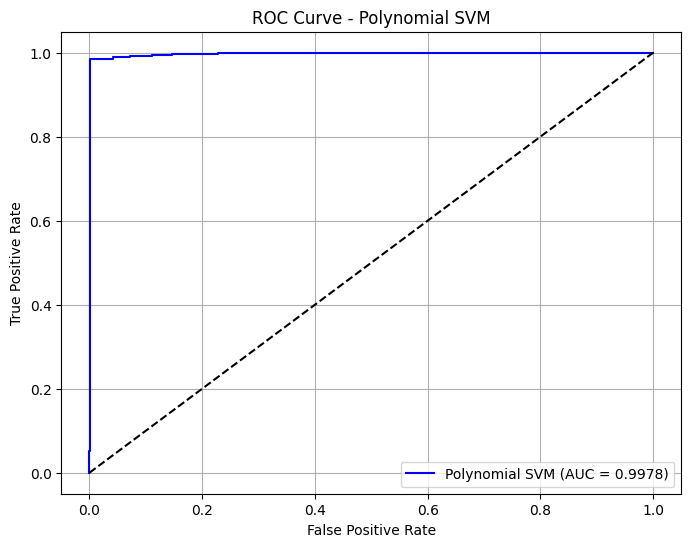

In [ ]:
# Compute overall ROC
y_score_poly = svm_poly_best_zoomed.decision_function(X_test)
fpr_poly, tpr_poly, _ = roc_curve(y_test_binarized.ravel(), y_score_poly.ravel())
auc_poly = roc_auc_score(y_test_binarized, y_score_poly, average="macro")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_poly, tpr_poly, label=f'Polynomial SVM (AUC = {auc_poly:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Polynomial SVM')
plt.legend()
plt.grid()
plt.show()

### Comparing two non linear kernals, we conclude RBF is the best SVM approach

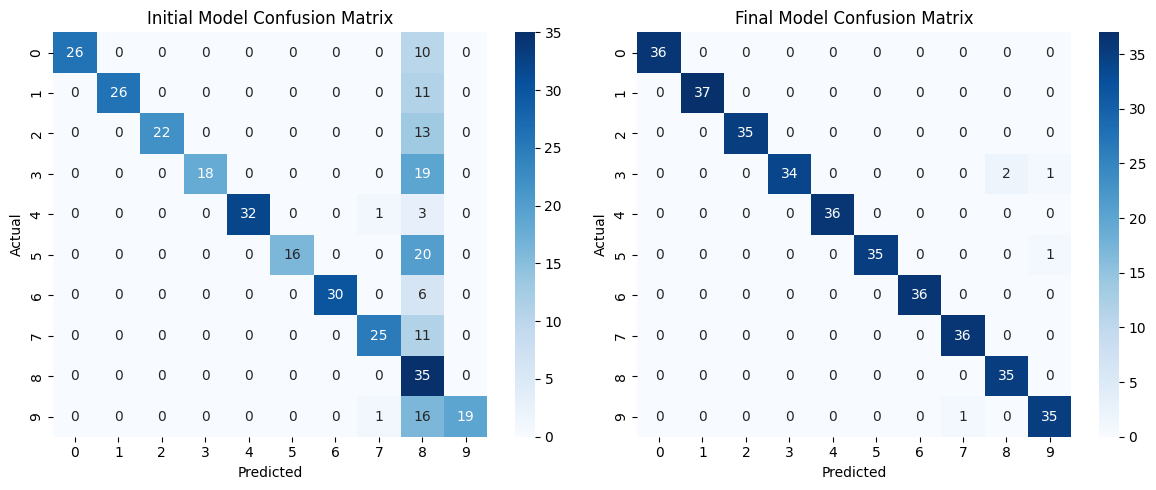

In [ ]:
# Plot the confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Initial Model Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Final Model Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification 5 - Linear Discriminant Analysis (LDA)

This Model was sourced from: (IBM 2023)

https://www.ibm.com/think/topics/linear-discriminant-analysis

In [ ]:
# 1. Loading Linear Discriminant Analysis (LDA) Classifier
lda = LinearDiscriminantAnalysis()

In [ ]:
# 2. Cross-Validation
# Initialize StratifiedKFold cross-validation with 5 folds, shuffling the data to enhance randomness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lda, X, y, cv=cv, scoring='accuracy')

### Evaluate the LDA Model

In [ ]:
# Output cross-validation results:
print(f"Cross-validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-validation Accuracy: {cv_scores.mean():.2f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.2f}")

Cross-validation Accuracy Scores: [0.94166667 0.95555556 0.9637883  0.95821727 0.94707521]
Mean Cross-validation Accuracy: 0.95
Standard Deviation of CV Accuracy: 0.01


In [ ]:
# 3. Final Model Training and Test Set Evaluation
# After validating the model's performance using cross-validation, we train the final LDA model on the training set
# and assess its accuracy on the test set.
lda.fit(X_train, y_train)  # Train the LDA model using the training data.
y_pred_test = lda.predict(X_test)  # Generate predictions on the test set.

In [ ]:
# 4. Model Evaluation
print("\n--- Test Set Performance ---")
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("\n--- ROC AUC Performance ---")
print(f"Test Set ROC AUC: {roc_auc_score(y_test_binarized, lda.predict_proba(X_test)):.4f}")
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))


--- Test Set Performance ---
Test Set Accuracy: 0.9444

--- ROC AUC Performance ---
Test Set ROC AUC: 0.9970

Confusion Matrix (Test Set):
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  1]
 [ 0  0 34  1  0  0  0  0  0  0]
 [ 0  0  0 31  0  1  0  0  4  1]
 [ 0  1  0  0 35  0  0  0  0  0]
 [ 0  0  0  0  0 33  0  0  1  2]
 [ 0  0  0  0  0  0 35  0  0  1]
 [ 0  0  0  0  0  0  0 35  0  1]
 [ 0  2  0  0  0  0  0  0 33  0]
 [ 0  0  0  0  0  1  0  1  2 32]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        37
           2       1.00      0.97      0.99        35
           3       0.97      0.84      0.90        37
           4       1.00      0.97      0.99        36
           5       0.94      0.92      0.93        36
           6       1.00      0.97      0.99        36
           7       0.97      0.97      0.97        36
       

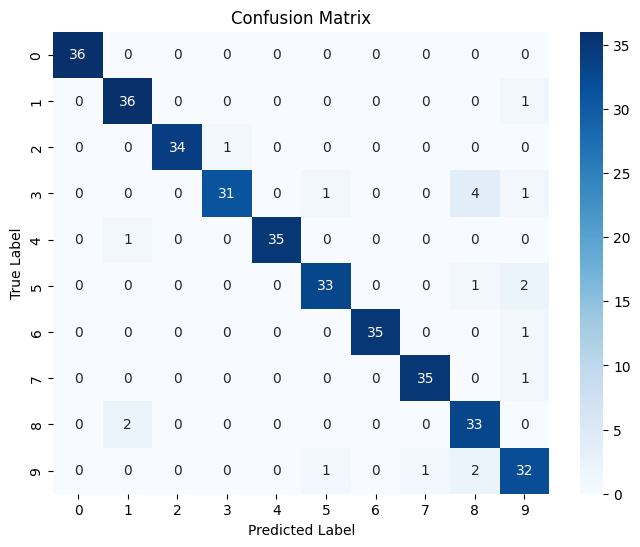

In [ ]:
# 5. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# 6. ROC Curve and AUC Score Calculation
y_score = lda.predict_proba(X_test)
n_classes = 10

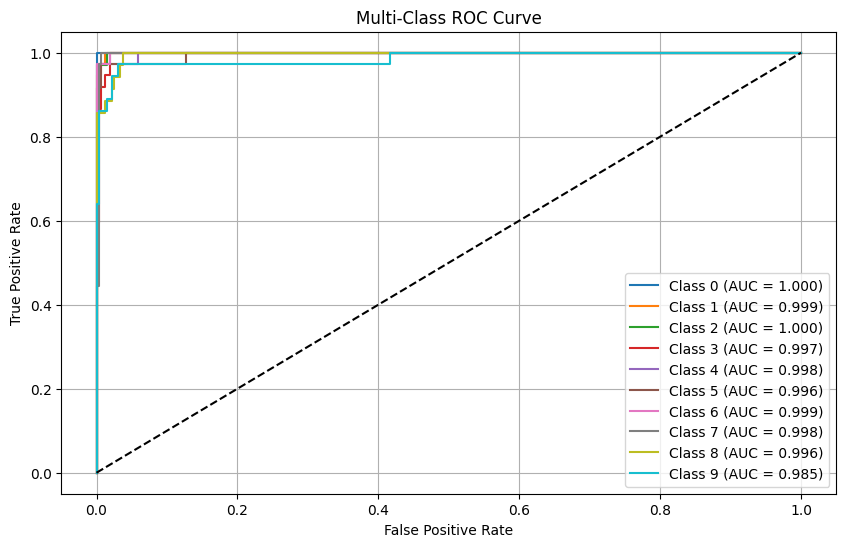

In [ ]:
# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.3f})')

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid()
plt.show()

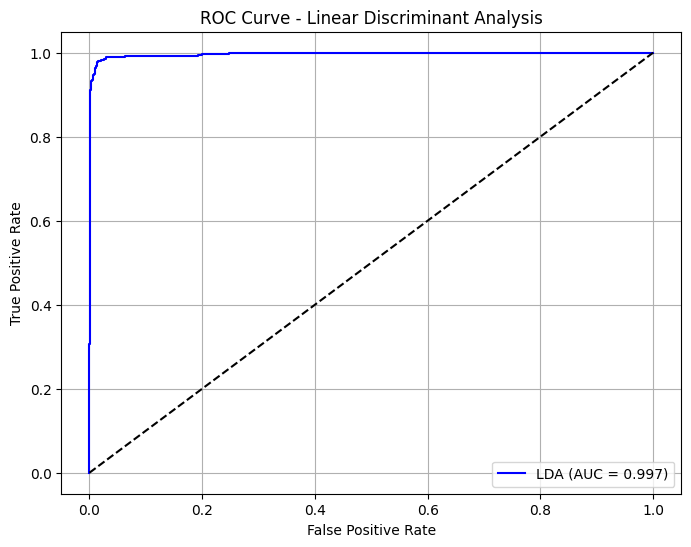

In [ ]:
# Compute ROC curve for overall model performance
lda_fpr, lda_tpr, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())

# Compute overall AUC score
lda_auc = roc_auc_score(y_test_binarized, y_score, average="macro", multi_class="ovr")

# ROC Curve for LDA
plt.figure(figsize=(8, 6))
plt.plot(lda_fpr, lda_tpr, label=f'LDA (AUC = {lda_auc:.3f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Linear Discriminant Analysis')
plt.legend()
plt.grid()
plt.show()


Number of misclassified samples: 20


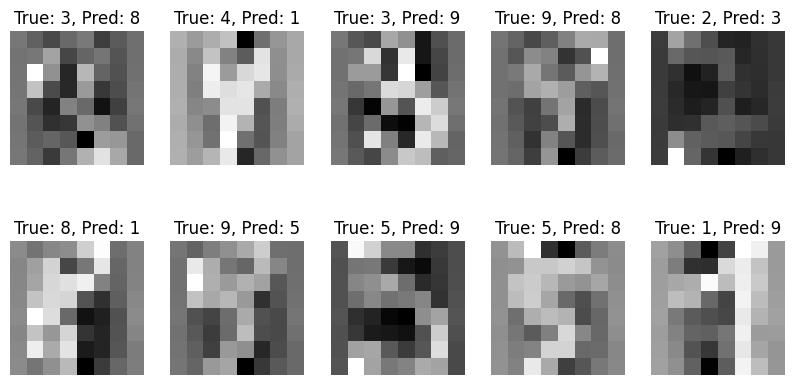

In [ ]:
# Visualize Misclassified Images (10 of them)
misclassified = np.where(y_pred_test != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified)}")
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), misclassified[:10]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred_test[idx]}")
    ax.axis('off')
plt.show()

## Classification 6 - k-Nearest Neighbours (k-NN)

In [ ]:
# Loading k-nn classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Train the classifier
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)

#### Evaluate the k-nearest model

In [ ]:
# Evaluate the model
knn_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {knn_accuracy}")

# Confusion Matrix
knn_cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{knn_cm}")

# ROC AUC Score (for binary classification)

knn_roc_auc = roc_auc_score(y_test_binarized, knn.predict_proba(X_test), multi_class='ovr')
print(f"ROC AUC Score: {knn_roc_auc}")

# Calculate the balanced accuracy score
knn_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {knn_balanced_accuracy}")

Accuracy: 0.9777777777777777
Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 35  0  0  0  0  1  0]
 [ 0  0  0  0 35  0  0  1  0  0]
 [ 0  0  0  0  0 35  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  0  1  1  1  1  0 32]]
ROC AUC Score: 0.9951809934578453
Balanced Accuracy: 0.9779279279279279


### Hyper Parameter Tuning

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize GridSearchCV with cross-validation
knn_grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='balanced_accuracy')

# Fit the model to find the best parameters
knn_grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = knn_grid_search.best_params_
best_knn = knn_grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

# Make predictions with the best estimator
best_knn_pred = best_knn.predict(X_test)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


### Evaluate the final model

In [ ]:
# Evaluate the model with the best estimator
knn_best_acc = accuracy_score(y_test, best_knn_pred)
print(f"Best Accuracy: {knn_best_acc}")

# Confusion Matrix
knn_best_cm = confusion_matrix(y_test, best_knn_pred)
print(f"Best Confusion Matrix:\n{knn_best_cm}")

# Calculate the balanced accuracy score
knn_best_balanced_acc = balanced_accuracy_score(y_test, best_knn_pred)
print(f"Best Balanced Accuracy: {knn_best_balanced_acc}")

# Evaluate the model with the ROC AUC
knn_roc_aoc_best = roc_auc_score(y_test_binarized, best_knn.predict_proba(X_test), multi_class='ovr')
print(f"Best ROC AUC: {knn_roc_aoc_best}")

Best Accuracy: 0.9777777777777777
Best Confusion Matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 35  0  0  0  0  1  0]
 [ 0  0  0  0 35  0  0  1  0  0]
 [ 0  0  0  0  0 35  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 35  0]
 [ 0  0  0  0  1  1  1  1  0 32]]
Best Balanced Accuracy: 0.9779279279279279
Best ROC AUC: 0.9952715585854476


In [ ]:
# Creating a k-Nearest Neighbours metric table

knn_table = PrettyTable()
table_metrics(knn_table, knn_balanced_accuracy, knn_roc_auc, knn_best_balanced_acc, knn_roc_aoc_best)

+--------------------------+--------------------+--------------------+
|          Metric          |   Initial Model    |    Final Model     |
+--------------------------+--------------------+--------------------+
|    Balanced Accuracy     | 0.9779279279279279 | 0.9779279279279279 |
| ROC AUC (macro averaged) | 0.9951809934578453 | 0.9952715585854476 |
+--------------------------+--------------------+--------------------+


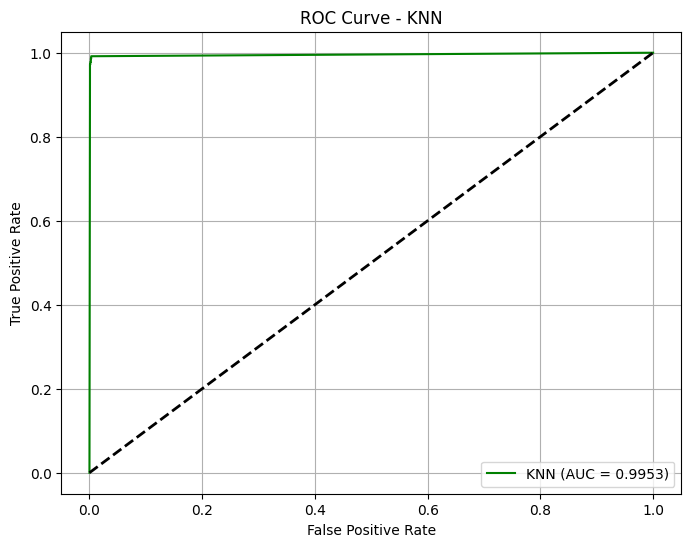

In [ ]:
# Compute ROC curve and AUC score (One-vs-Rest)
y_score_knn = knn_grid_search.predict_proba(X_test)
fpr_knn, tpr_knn, _ = roc_curve(y_test_binarized.ravel(), y_score_knn.ravel())
auc_knn = roc_auc_score(y_test_binarized, y_score_knn, average="macro")

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Reference line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## Classification 7 - Naïve Bayes

This Model was sourced from: (scikit-learn, 2025a)

https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

In [ ]:
### Selecting the gNB model and splitting the data
gnb = GaussianNB()
gnb.fit(X_train, y_train)

### Make Predictions
y_pred = gnb.predict(X_test)

### Evaluating the model

In [ ]:
print(f'Classification Report for gNB: \n{classification_report(y_test, y_pred)}')

Classification Report for gNB: 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.85      0.46      0.60        37
           2       0.92      0.69      0.79        35
           3       0.95      0.49      0.64        37
           4       0.85      0.61      0.71        36
           5       0.92      0.92      0.92        36
           6       0.80      1.00      0.89        36
           7       0.63      0.94      0.76        36
           8       0.45      0.86      0.59        35
           9       0.90      0.75      0.82        36

    accuracy                           0.77       360
   macro avg       0.82      0.77      0.77       360
weighted avg       0.82      0.77      0.77       360



In [ ]:
### Accuracy Score and ROC AUC Score

gnb_acc = accuracy_score(y_test, y_pred)
gnb_roc_auc = roc_auc_score(y_test, gnb.predict_proba(X_test), multi_class='ovr')
print(f'Accuracy Score: {gnb_acc:.2f}')
print(f'ROC AUC Score: {gnb_roc_auc:.3f}')

Accuracy Score: 0.77
ROC AUC Score: 0.971


<Figure size 800x600 with 0 Axes>

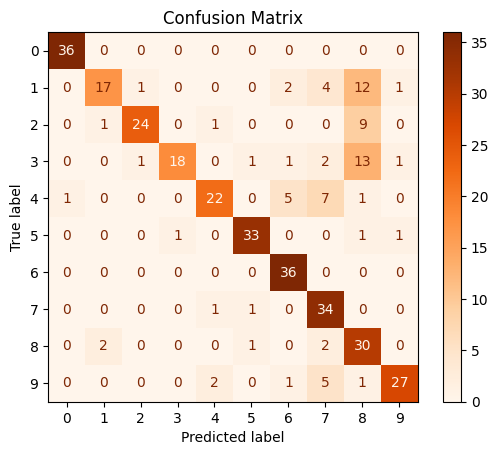

In [ ]:
### Confusion Matrix
plt.figure(figsize = (8,6));

gnb_cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=gnb_cm);


disp.plot(cmap='Oranges');
plt.title('Confusion Matrix');

### Hypertuning

In [ ]:
### Checking the Model Parameters
gnb.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [ ]:
### Tuning different parameters

parameters = {'var_smoothing' : np.logspace(0,-9,)}

### Selecting a second gNB model and grid search
gnb2 = GaussianNB()
gnb_grid = GridSearchCV(gnb2, parameters)

### Splitting the data
gnb_grid.fit(X_train, y_train)

GridSearchCV(estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e+00, 6.55128557e-01, 4.29193426e-01, 2.81176870e-01,
       1.84206997e-01, 1.20679264e-01, 7.90604321e-02, 5.17947468e-02,
       3.39322177e-02, 2.22299648e-02, 1.45634848e-02, 9.54095476e-03,
       6.25055193e-03, 4.09491506e-03, 2.68269580e-03, 1.75751062e-03,
       1.15139540e-03, 7.54312006e-04, 4.9417133...
       3.90693994e-05, 2.55954792e-05, 1.67683294e-05, 1.09854114e-05,
       7.19685673e-06, 4.71486636e-06, 3.08884360e-06, 2.02358965e-06,
       1.32571137e-06, 8.68511374e-07, 5.68986603e-07, 3.72759372e-07,
       2.44205309e-07, 1.59985872e-07, 1.04811313e-07, 6.86648845e-08,
       4.49843267e-08, 2.94705170e-08, 1.93069773e-08, 1.26485522e-08,
       8.28642773e-09, 5.42867544e-09, 3.55648031e-09, 2.32995181e-09,
       1.52641797e-09, 1.00000000e-09])})

In [ ]:
### Retrieving the best estimators
best_gnb = gnb_grid.best_estimator_
print(f'Best Estimators: \n {best_gnb}')
### Retrieving the best Parameters
best_gnb_params = gnb_grid.best_params_
print(f'Best Parameters: \n {best_gnb_params}')

Best Estimators: 
 GaussianNB(var_smoothing=0.12067926406393285)
Best Parameters: 
 {'var_smoothing': 0.12067926406393285}


In [ ]:
### Second Model Prediciton
gnb_best_pred = best_gnb.predict(X_test)

In [ ]:
### Classification Report of the best Model

print('Below displays the Classification Report on the Model: \n\n',classification_report(y_test, gnb_best_pred))

Below displays the Classification Report on the Model: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.85      0.78      0.82        37
           2       0.88      0.83      0.85        35
           3       0.97      0.78      0.87        37
           4       0.97      0.97      0.97        36
           5       0.92      0.92      0.92        36
           6       0.97      0.97      0.97        36
           7       0.83      0.97      0.90        36
           8       0.69      0.83      0.75        35
           9       0.83      0.81      0.82        36

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360



In [ ]:
# Evaluating the optimised model
gnb_best_acc = accuracy_score(y_test, gnb_best_pred)
gnb_roc_auc_best = roc_auc_score(y_test, best_gnb.predict_proba(X_test), multi_class='ovr')
print(f'Best GnB Accuracy Score: {gnb_best_acc:.4f}')
print(f'Best GnB ROC AUC Score: {gnb_roc_auc_best:.4f}')

Best GnB Accuracy Score: 0.8861
Best GnB ROC AUC Score: 0.9756


<Figure size 1600x1200 with 0 Axes>

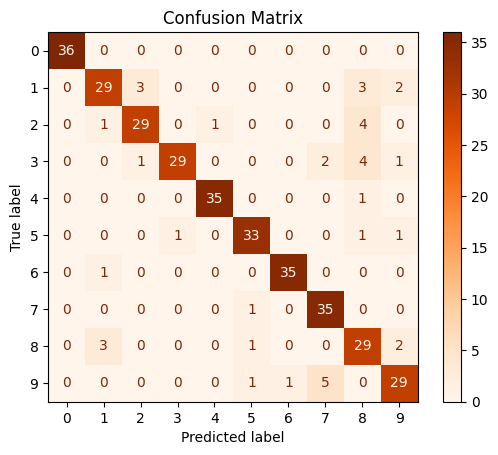

In [ ]:
### Confusion Matrix
plt.figure(figsize = (8,6), dpi = 200);

cm = confusion_matrix(y_test, gnb_best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm);


disp.plot(cmap='Oranges');
plt.title('Confusion Matrix');

In [ ]:
gnb_y_score = gnb.predict_proba(X_test)
gnb_n_classes = 10

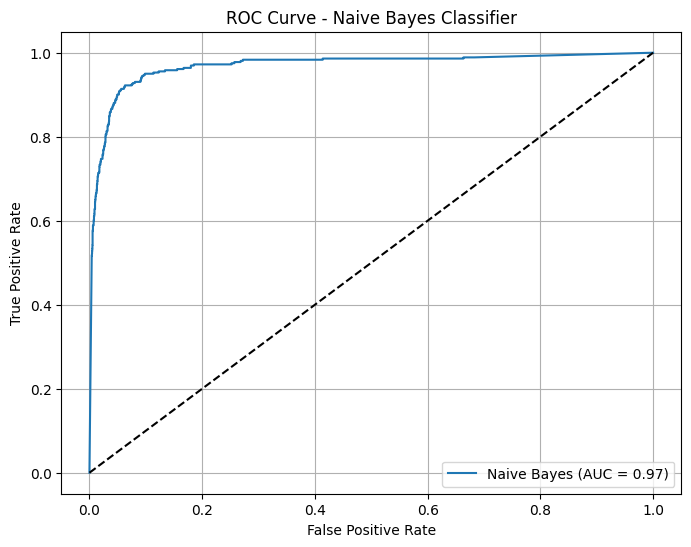

In [ ]:
# ROC Curve for Naive Bayes
gnb_fpr, gnb_tpr, _ = roc_curve(y_test_binarized.ravel(), gnb.predict_proba(X_test).ravel())

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(gnb_fpr, gnb_tpr, label=f'Naive Bayes (AUC = {gnb_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes Classifier')
plt.legend()
plt.grid()
plt.show()

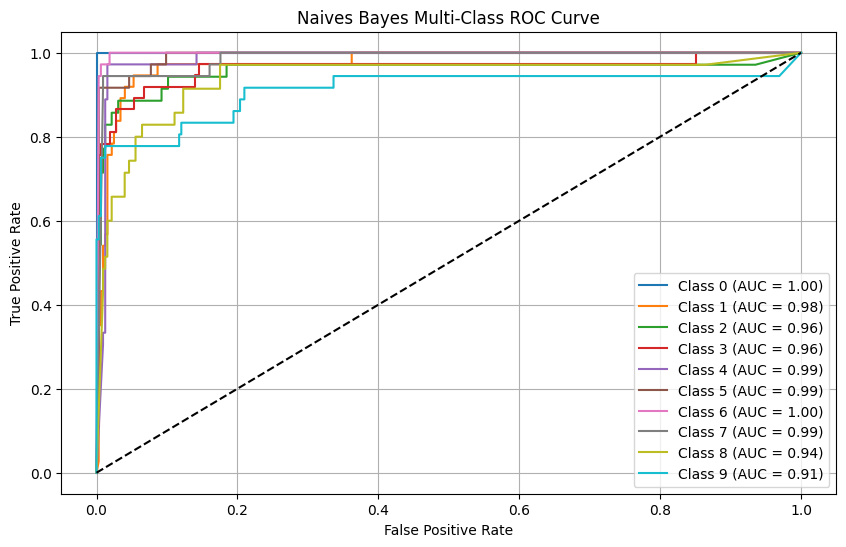

In [ ]:
# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 6))
for i in range(gnb_n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], gnb_y_score[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], gnb_y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naives Bayes Multi-Class ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("\nImprovement:", f"{(gnb_best_acc - gnb_acc) * 100:.2f}%" if gnb_best_acc > gnb_acc else "No improvement")
gnb_table = PrettyTable()
table_metrics(gnb_table, gnb_acc, gnb_roc_auc, gnb_best_acc, gnb_roc_auc_best)


Improvement: 11.67%
+--------------------------+--------------------+--------------------+
|          Metric          |   Initial Model    |    Final Model     |
+--------------------------+--------------------+--------------------+
|    Balanced Accuracy     | 0.7694444444444445 | 0.8861111111111111 |
| ROC AUC (macro averaged) | 0.9706471370925935 | 0.9755793553633824 |
+--------------------------+--------------------+--------------------+


## Classification 8 - XGBoost (Extreme Gradient Boosting)

This Model was sourced from: (xgboost.readthedocs.io. n.d.)

https://xgboost.readthedocs.io/en/stable/

In [ ]:
# 1. Baseline XGBoost Model
baseline_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=13)
baseline_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:00:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
# Predictions & Evaluation (Baseline Model)
y_pred_baseline = baseline_model.predict(X_test)
y_score_baseline = baseline_model.predict_proba(X_test)

### Evaluate the Gradient Boosting model

In [ ]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("\n--- Baseline XGBoost Model Performance ---")
print(f"Accuracy: {baseline_accuracy:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_baseline))
print("Classification Report:\n", classification_report(y_test, y_pred_baseline))

# Compute ROC curve and AUC score for baseline model
baseline_fpr, baseline_tpr, _ = roc_curve(y_test_binarized.ravel(), y_score_baseline.ravel())
baseline_auc = roc_auc_score(y_test_binarized, y_score_baseline, average="macro")


--- Baseline XGBoost Model Performance ---
Accuracy: 0.9639
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  1 34  0  0  0  0  0  0  0]
 [ 0  1  1 33  0  0  1  1  0  0]
 [ 0  0  0  0 35  0  0  1  0  0]
 [ 0  1  0  0  1 34  0  0  0  0]
 [ 0  0  0  0  1  0 35  0  0  0]
 [ 0  0  0  1  1  0  0 34  0  0]
 [ 0  0  0  0  0  0  0  0 34  1]
 [ 0  0  0  1  0  0  0  0  0 35]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.93      1.00      0.96        37
           2       0.97      0.97      0.97        35
           3       0.94      0.89      0.92        37
           4       0.92      0.97      0.95        36
           5       1.00      0.94      0.97        36
           6       0.97      0.97      0.97        36
           7       0.94      0.94      0.94        36
           8       1.00      0.97      0.99        35
           9       0.97 

### Hyper Parameter Tuning

In [ ]:
# 2. First Round of GridSearchCV
param_grid_1 = {
    "max_depth": [3, 5, 7],  # Tree depth
    "learning_rate": [0.1, 0.01, 0.05],  # Step size
    "n_estimators": [50, 100, 200],  # Number of trees
    'subsample': [0.8, 1.0],  # Fraction of samples used per tree
    'colsample_bytree': [0.8, 1.0]  # Fraction of features used per tree

}

xgb_tuned = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=13)
grid_search_1 = GridSearchCV(xgb_tuned, param_grid_1, scoring="accuracy", cv=3, verbose=1, n_jobs=-1)
grid_search_1.fit(X_train, y_train)


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:02:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=13, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.1, 0.01, 0.05],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [ ]:
# Best parameters from first GridSearch
best_params_1 = grid_search_1.best_params_
print("\n--- First GridSearch Best Hyperparameters ---")
print(best_params_1)


--- First GridSearch Best Hyperparameters ---
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# 3. Second Round of GridSearch
# Fine-tune each parameters by testing values around the best one from the first grid search.
param_grid_2 = {
    "max_depth": [3 - 1, 3, 3 + 1],
    "learning_rate": [0.1 * 0.5, 0.1, 0.1 * 1.5],
    "n_estimators": [200 - 50, 200, 200 + 50],
    "subsample": [0.8 - 0.1, 0.8, 0.8 + 0.1],
    "colsample_bytree": [0.8 - 0.1, 0.8, 0.8 + 0.1],

}

grid_search_2 = GridSearchCV(xgb_tuned, param_grid_2, scoring="accuracy", cv=3, verbose=1, n_jobs=-1)
grid_search_2.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:08:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=13, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7000000000000001, 0.8, 0.9],
                         'learning_rate': [0.05, 0.1, 0.15000000000000002],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [150, 200, 250],
                         'subsample': [0.7000000000000001, 0.8, 0.9]},
             scoring='accuracy', verbose=1)

In [ ]:
# Best parameters from second GridSearch
best_params_2 = grid_search_2.best_params_
print("\n--- Second GridSearch Best Hyperparameters ---")
print(best_params_2)



--- Second GridSearch Best Hyperparameters ---
{'colsample_bytree': 0.7000000000000001, 'learning_rate': 0.15000000000000002, 'max_depth': 2, 'n_estimators': 250, 'subsample': 0.8}


In [ ]:
# 4. Train XGBoost Model with Best Parameters
best_model = grid_search_2.best_estimator_
best_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:08:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7000000000000001, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15000000000000002,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
# Predictions & Evaluation (Tuned Model)
y_pred_tuned = best_model.predict(X_test)
y_score_tuned = best_model.predict_proba(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print("\n--- Tuned XGBoost Model Performance ---")
print(f"Accuracy: {tuned_accuracy:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))


--- Tuned XGBoost Model Performance ---
Accuracy: 0.9667
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  1  0 33  0  0  0  2  1  0]
 [ 0  0  0  0 35  0  0  0  1  0]
 [ 0  0  0  0  0 33  0  0  1  2]
 [ 0  0  0  0  1  0 35  0  0  0]
 [ 0  0  0  0  1  0  0 35  0  0]
 [ 0  0  0  1  0  0  0  0 33  1]
 [ 0  0  0  0  0  0  0  0  0 36]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        35
           3       0.97      0.89      0.93        37
           4       0.95      0.97      0.96        36
           5       1.00      0.92      0.96        36
           6       1.00      0.97      0.99        36
           7       0.95      0.97      0.96        36
           8       0.92      0.94      0.93        35
           9       0.92    

In [ ]:
# Compute ROC curve and AUC score for tuned model
tuned_fpr, tuned_tpr, _ = roc_curve(y_test_binarized.ravel(), y_score_tuned.ravel())
tuned_auc = roc_auc_score(y_test_binarized, y_score_tuned, average="macro")

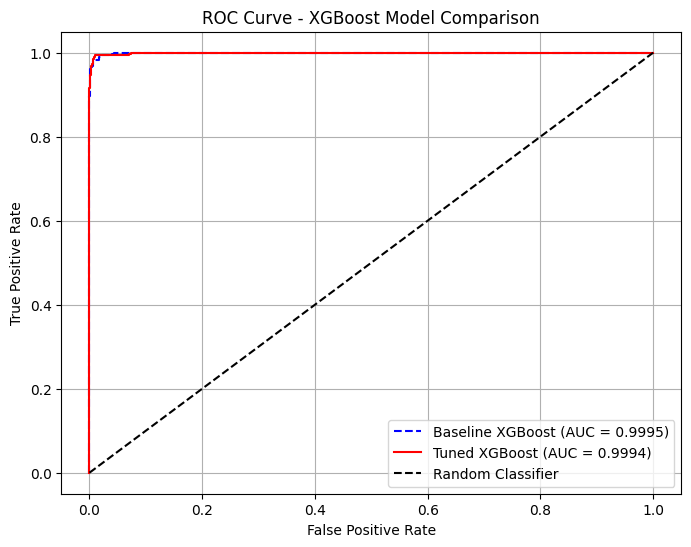

In [ ]:
# 5. Plot ROC Curve for Baseline vs Tuned Model
plt.figure(figsize=(8, 6))
plt.plot(baseline_fpr, baseline_tpr, label=f'Baseline XGBoost (AUC = {baseline_auc:.4f})', linestyle="--", color='blue')
plt.plot(tuned_fpr, tuned_tpr, label=f'Tuned XGBoost (AUC = {tuned_auc:.4f})', linestyle="-", color='red')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")  # Diagonal reference line

# Formatting the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Model Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 6. Compare Baseline vs Tuned Model
print("\n--- Model Comparison ---")
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Tuned Accuracy: {tuned_accuracy:.4f}")
print("Improvement:", f"{(tuned_accuracy - baseline_accuracy) * 100:.2f}%" if tuned_accuracy > baseline_accuracy else "No improvement")


--- Model Comparison ---
Baseline Accuracy: 0.9639
Tuned Accuracy: 0.9667
Improvement: 0.28%


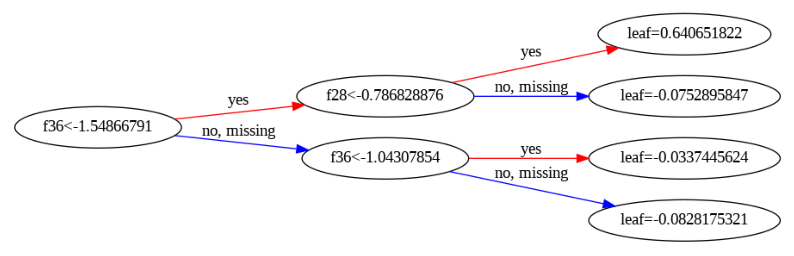

In [ ]:
# Plot the first tree from the tuned model
plt.figure(figsize=(10, 5))
xgb.plot_tree(best_model, num_trees=0, rankdir="LR", ax=plt.gca())  # Left to Right
plt.show()

Number of misclassified samples: 12


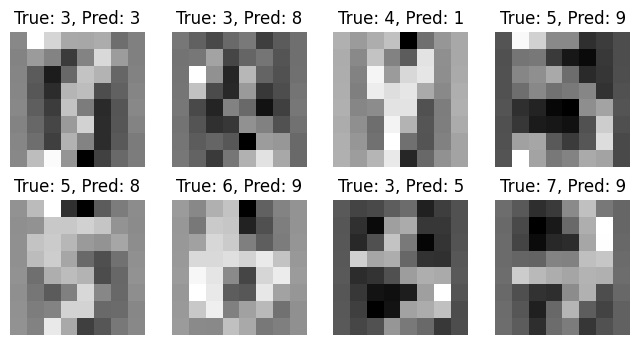

In [ ]:
# Visualize Misclassified Images
misclassified = np.where(y_pred_tuned != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified)}")
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, idx in zip(axes.ravel(), misclassified[:8]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred_test[idx]}")
    ax.axis('off')
plt.show()

## Comparing all 8 classifiers

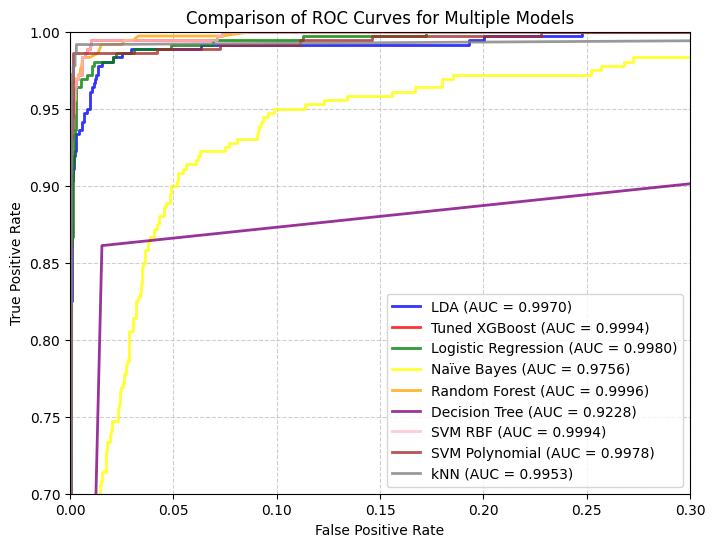

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(lda_fpr, lda_tpr, label=f'LDA (AUC = {lda_auc:.4f})', color='blue', lw=2, alpha=0.8)
plt.plot(tuned_fpr, tuned_tpr, label=f'Tuned XGBoost (AUC = {tuned_auc:.4f})', color='red', lw=2, alpha=0.8)
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_best_roc_auc:.4f})', color='green', lw=2, alpha=0.8)
plt.plot(gnb_fpr, gnb_tpr, label=f'Naïve Bayes (AUC = {gnb_roc_auc_best:.4f})', color='yellow', lw=2, alpha=0.8)
plt.plot(rfc_fpr, rfc_tpr, label=f'Random Forest (AUC = {best_rfc_roc_auc:.4f})', color='orange', lw=2, alpha=0.8)
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_best_roc_auc:.4f})', color='purple', lw=2, alpha=0.8)
plt.plot(fpr_svm, tpr_svm, label=f'SVM RBF (AUC = {auc_svm:.4f})', color='pink', lw=2, alpha=0.8)
plt.plot(fpr_poly, tpr_poly, label=f'SVM Polynomial (AUC = {auc_poly:.4f})', color='brown', lw=2, alpha=0.8)
plt.plot(fpr_knn, tpr_knn, label=f'kNN (AUC = {auc_knn:.4f})', color='gray', lw=2, alpha=0.8)

# Plot diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 0.3])
plt.ylim([0.7, 1.0])
# Labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves for Multiple Models')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
auc_scores = {
    "LDA": lda_auc,
    "XGBoost": tuned_auc,
    "SVM (RBF)": auc_svm,
    "SVM (Polynomial)": auc_poly,
    "KNN": auc_knn,
    "Logistic Regression": lr_best_roc_auc,
    "Naïve Bayes": gnb_roc_auc_best,
    "Random Forest": best_rfc_roc_auc,
    "Decision Tree": dt_best_roc_auc
}

# Print sorted AUC scores
for model, auc in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: AUC = {auc:.4f}")

best_model = max(auc_scores, key=auc_scores.get)
best_auc = auc_scores[best_model]

print(f"Best Model: {best_model} with AUC = {best_auc:.4f}")

Random Forest: AUC = 0.9996
XGBoost: AUC = 0.9994
SVM (RBF): AUC = 0.9994
Logistic Regression: AUC = 0.9980
SVM (Polynomial): AUC = 0.9978
LDA: AUC = 0.9970
KNN: AUC = 0.9953
Naïve Bayes: AUC = 0.9756
Decision Tree: AUC = 0.9228
Best Model: Random Forest with AUC = 0.9996


# References

Harvard Referencing:

AI_NA (2019). How change the color of boxes in confusion matrix using sklearn? [online] Stack Overflow. Available at: https://stackoverflow.com/questions/57043260/how-change-the-color-of-boxes-in-confusion-matrix-using-sklearn [Accessed 27 Feb. 27AD].

Codebasics (2019). Machine Learning Tutorial Python - 16: Hyper Parameter Tuning (GridSearchCV). YouTube. Available at: https://www.youtube.com/watch?v=HdlDYng8g9s [Accessed 27 Mar. 2025].

GeeksForGeeks (2023). Hyperparameter Tuning. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/hyperparameter-tuning/ [Accessed 27 Feb. 2025].

Normalized Nerd (2021). GridSearchCV | Hyperparameter Tuning | Machine Learning with Scikit-Learn Python. [online] YouTube. Available at: https://www.youtube.com/watch?v=TvB_3jVIHhg [Accessed 27 Feb. 2025].

SciKit Learn (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html [Accessed 2 Mar. 2025].

Scikit Learn (2012). 3.2. Tuning the hyper-parameters of an estimator — scikit-learn 0.22 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/grid_search.html [Accessed 2 Feb. 2025].

Scikit-learn (2019). 3.2.4.3.1. sklearn.ensemble.RandomForestClassifier — scikit-learn 0.21.3 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier [Accessed 26 Feb. 2025].

scikit-learn (2025a). sklearn.naive_bayes.GaussianNB — scikit-learn 0.22.1 documentation. [online] scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html [Accessed 17 Feb. 2025].

scikit-learn. (2015). balanced_accuracy_score. [online] Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html#sklearn.metrics.balanced_accuracy_score [Accessed 19 Feb. 2025].

scikit-learn. (2025b). sklearn.metrics.ConfusionMatrixDisplay. [online] Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html [Accessed 27 Feb. 2025].

Scikit-learn.org. (2019). sklearn.metrics.roc_auc_score — scikit-learn 0.21.3 Documentation. [online] Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score [Accessed 26 Feb. 2025].

Stack Overflow. (2025). Machine Learning - How to Tune GaussianNB? [online] Available at: https://stackoverflow.com/questions/39828535/how-to-tune-gaussiannb [Accessed 19 Feb. 2025].

Google for Developers (2025) Machine Learning Crash Course: Neural Networks Intro, Youtu.be. Google for Developers. Available at: https://youtu.be/0kZIGB_dG80?list=PLOU2XLYxmsILTKLltkh859KJ9BizDvd_S (Accessed: 28 February 2025).

MIT OpenCourseWare (2014) 16. Learning: Support Vector Machines, www.youtube.com. MIT OpenCourseWare. Available at: https://youtu.be/_PwhiWxHK8o (Accessed: 15 February 2023).

scikit learn (2018) 1.4. Support Vector Machines, Scikit-learn.org. Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/svm.html (Accessed: 10 February 2025).

Scikit-learn.org (2019a) 1.4. Support Vector Machines — scikit-learn 0.23.2 documentation, scikit-learn.org. Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/svm.html#svm-kernels (Accessed: 27 February 2025).

Scikit-learn.org (2019b) 1.6. Nearest Neighbors — scikit-learn 0.21.3 documentation, Scikit-learn.org. Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/neighbors.html (Accessed: 16 February 2025).

Scikit-learn.org (2019c) RBF SVM parameters — scikit-learn 0.22 documentation, Scikit-learn.org. Scikit-learn.org. Available at: https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html#sphx-glr-auto-examples-svm-plot-rbf-parameters-py (Accessed: 26 February 2025).

Scikit-learn.org (2019d) sklearn.model_selection.GridSearchCV — scikit-learn 0.22 documentation, Scikit-learn.org. Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV (Accessed: 23 February 2025).

Sklearn (2019) RBF SVM parameters — scikit-learn 0.21.3 documentation, Scikit-learn.org. Scikit-learn.org. Available at: https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html (Accessed: 21 February 2025).

Banerjee, P. (2020). A Guide on XGBoost hyperparameters tuning. [online] kaggle.com. Available at: https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning [Accessed 27 Feb. 2025].

Coursera. (n.d.). Advanced Learning Algorithms. [online] Available at: https://www.coursera.org/learn/advanced-learning-algorithms?specialization=machine-learning-introduction [Accessed 27 Feb. 2025].

IBM (2023). Linear Discriminant Analysis. [online] Ibm.com. Available at: https://www.ibm.com/think/topics/linear-discriminant-analysis [Accessed 20 Feb. 2025].

Mandar Karhade, MD. PhD (2022). Everything about Linear Discriminant Analysis (LDA). [online] Medium. Available at: https://medium.com/geekculture/everything-about-linear-discriminant-analysis-lda-c22adc8f5ea0 [Accessed 20 Feb. 2025].

Niketanpanchal (2020). XGBoost Classifier Hand Written Digit recognition - Analytics Vidhya - Medium. [online] Medium. Available at: https://medium.com/analytics-vidhya/xgboost-classifier-hand-written-digit-recognition-219acedfef13 [Accessed 27 Feb. 2025].

SciKit Learn (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html [Accessed 27 Feb. 2025].

scikit-learn. (2025a). Comparison of LDA and PCA 2D projection of Iris dataset. [online] Available at: https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html#sphx-glr-auto-examples-decomposition-plot-pca-vs-lda-py [Accessed 20 Feb. 2025].

scikit-learn. (2025b). Linear and Quadratic Discriminant Analysis with covariance ellipsoid. [online] Available at: https://scikit-learn.org/stable/auto_examples/classification/plot_lda_qda.html#sphx-glr-auto-examples-classification-plot-lda-qda-py [Accessed 20 Feb. 2025].

scikit-learn.org. (n.d.). 1.2. Linear and Quadratic Discriminant Analysis — scikit-learn 0.23.2 documentation. [online] Available at: https://scikit-learn.org/stable/modules/lda_qda.html [Accessed 20 Feb. 2025].

scikit-learn.org. (n.d.). sklearn.metrics.roc_auc_score — scikit-learn 0.23.2 documentation. [online] Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html [Accessed 21 Feb. 2025].

StatQuest with Josh Starmer (2020). XGBoost in Python from Start to Finish. [online] YouTube. Available at: https://www.youtube.com/watch?v=GrJP9FLV3FE [Accessed 27 Feb. 2025].

xgboost.readthedocs.io. (n.d.). XGBoost Documentation — xgboost 1.7.2 documentation. [online] Available at: https://xgboost.readthedocs.io/en/stable/# [Accessed 27 Feb. 2025].

Xgboosting.com. (2024). Configure XGBoost ‘n_jobs’ Parameter | XGBoosting. [online] Available at: https://xgboosting.com/configure-xgboost-n_jobs-parameter/ [Accessed 27 Feb. 2025].

Scikit-learn.org. (2025). sklearn.tree.DecisionTreeClassifier — scikit-learn Documentation. [online] Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html [Accessed 26 Feb. 2025].

Scikit-learn.org. (2025). sklearn.metrics.confusion_matrix — scikit-learn Documentation. [online] Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html [Accessed 26 Feb. 2025].

Scikit-learn.org. (2025). sklearn.metrics.roc_auc_score — scikit-learn Documentation. [online] Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html [Accessed 26 Feb. 2025].

Stack Overflow. (2025). Hyperparameter tuning for DecisionTreeClassifier. [online] Available at:
https://stackoverflow.com/questions/49428469/hyperparameter-tuning-for-decisiontreeclassifier [Accessed 26 Feb. 2025]

Scikit-learn.org. (2025). sklearn.linear_model.LogisticRegression — scikit-learn Documentation. [online] Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html [Accessed 26 Feb. 2025].

Scikit-learn.org. (2025). sklearn.metrics.roc_auc_score — scikit-learn Documentation. [online] Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html [Accessed 26 Feb. 2025].

Scikit-learn.org. (2025). sklearn.model_selection.GridSearchCV — scikit-learn Documentation. [online] Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html [Accessed 26 Feb. 2025].

Stack Overflow. (2025). Hyperparameter tuning for Logistic Regression using GridSearchCV. [online] Available at:
https://stackoverflow.com/questions/30005419/hyperparameter-tuning-for-logistic-regression-using-gridsearchcv [Accessed 26 Feb. 2025].